# ⚛️ Análise do Dataset DGA — Modelos Quânticos de Machine Learning

Este notebook aplica **Quantum Machine Learning (QML)** ao problema de detecção de domínios DGA (Domain Generation Algorithm).

## Estrutura
1. Importações e Configurações
2. Carregamento e Feature Engineering
3. Redução de Dimensionalidade (PCA) para Circuitos Quânticos
4. **QSVM** — Quantum Support Vector Machine (Qiskit)
5. **VQC** — Variational Quantum Classifier (PennyLane)
6. Avaliação e Comparação com Modelos Clássicos

> **ℹ️ Nota sobre escala**: Modelos quânticos em simuladores clássicos são computacionalmente intensivos.  
> Utilizamos um **subset de 1.500 amostras** para treinamento e testes, o que é padrão em pesquisa de QML.  
> Os modelos clássicos de referência são re-treinados no **mesmo subset** para comparação justa.

## 1. Importações e Configurações

In [10]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import math
import time
from collections import Counter

# Visualização
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch

# Pré-processamento clássico
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay
)

# ── Qiskit ──────────────────────────────────────────────────────────────────
try:
    from qiskit import QuantumCircuit
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit_machine_learning.algorithms import QSVC
    from qiskit_algorithms.state_fidelities import ComputeUncompute
    from qiskit.primitives import StatevectorSampler as Sampler 
    import qiskit
    QISKIT_OK = True
    print(f'✅ Qiskit {qiskit.__version__} importado com sucesso!')
except ImportError as e:
    QISKIT_OK = False
    print(f'⚠️ Qiskit não disponível: {e}')

# ── PennyLane ───────────────────────────────────────────────────────────────
try:
    import pennylane as qml
    from pennylane import numpy as pnp
    PENNYLANE_OK = True
    print(f'✅ PennyLane {qml.__version__} importado com sucesso!')
except ImportError as e:
    PENNYLANE_OK = False
    print(f'⚠️ PennyLane não disponível: {e}')

# Estilo
plt.style.use('dark_background')
sns.set_palette('husl')
COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A29BFE', '#FD79A8']

# Parâmetros globais
SUBSET_SIZE = 1500    # amostras para treinamento quântico
N_QUBITS = 4          # qubits (dimensões do espaço de features)
RANDOM_STATE = 42
Q_TRAIN_SIZE = 1000   # amostras para treino quântico
Q_TEST_SIZE  = 500    # amostras para teste quântico

print(f'\n⚙️  Configuração Quântica:')
print(f'   Qubits: {N_QUBITS}')
print(f'   Subset total: {SUBSET_SIZE:,} amostras')
print(f'   Treino: {Q_TRAIN_SIZE:,} | Teste: {Q_TEST_SIZE:,}')

✅ Qiskit 2.3.0 importado com sucesso!
✅ PennyLane 0.42.3 importado com sucesso!

⚙️  Configuração Quântica:
   Qubits: 4
   Subset total: 1,500 amostras
   Treino: 1,000 | Teste: 500


## 2. Carregamento e Feature Engineering

In [2]:
# ── Feature Engineering (reutilizando lógica do notebook clássico) ──────────
def shannon_entropy(s):
    if len(s) == 0: return 0.0
    counts = Counter(s)
    total = len(s)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

def max_consecutive_consonants(s):
    consonants = set('bcdfghjklmnpqrstvwxyz')
    max_c = curr_c = 0
    for ch in s.lower():
        if ch in consonants:
            curr_c += 1
            max_c = max(max_c, curr_c)
        else:
            curr_c = 0
    return max_c

def extract_features(df):
    domains = df['domain'].str.lower()
    vowels = set('aeiou')
    consonants = set('bcdfghjklmnpqrstvwxyz')
    f = pd.DataFrame()
    f['length'] = domains.str.len()
    f['entropy'] = domains.apply(shannon_entropy)
    f['vowel_ratio'] = domains.apply(lambda x: sum(c in vowels for c in x) / max(len(x), 1))
    f['digit_ratio'] = domains.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1))
    f['consonant_ratio'] = domains.apply(lambda x: sum(c in consonants for c in x) / max(len(x), 1))
    f['unique_chars'] = domains.apply(lambda x: len(set(x)))
    f['max_consec_consonants'] = domains.apply(max_consecutive_consonants)
    f['has_hyphen'] = domains.str.contains('-').astype(int)
    f['has_digits'] = domains.str.contains(r'\d').astype(int)
    f['length_entropy'] = f['length'] * f['entropy']
    return f

# Carregar dataset completo
print('📂 Carregando dataset DGA...')
df_full = pd.read_csv('dga_data.csv')
print(f'   Shape completo: {df_full.shape}')

# Criar subset estratificado
df_subset, _ = train_test_split(
    df_full, train_size=SUBSET_SIZE,
    stratify=df_full['isDGA'], random_state=RANDOM_STATE
)
print(f'   Shape subset: {df_subset.shape}')
print(f'   Classes: {df_subset["isDGA"].value_counts().to_dict()}')

# Extrair features
print('\n⚙️ Extraindo features...')
X_raw = extract_features(df_subset)
le = LabelEncoder()
y_all = le.fit_transform(df_subset['isDGA'])
print(f'   Features: {X_raw.shape[1]} | Target: {dict(zip(le.classes_, range(len(le.classes_))))}')

X_raw.describe()

📂 Carregando dataset DGA...
   Shape completo: (160000, 4)
   Shape subset: (1500, 4)
   Classes: {'dga': 750, 'legit': 750}

⚙️ Extraindo features...
   Features: 10 | Target: {'dga': 0, 'legit': 1}


,length,entropy,vowel_ratio,digit_ratio,consonant_ratio,unique_chars,max_consec_consonants,has_hyphen,has_digits,length_entropy
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,13.454667,3.125653,0.279471,0.057384,0.660692,10.132667,4.253333,0.026667,0.162667,45.391333
std,6.590567,0.591264,0.144592,0.145293,0.157780,4.175167,3.074756,0.161161,0.369184,29.597853
min,2.000000,0.918296,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000
25%,9.000000,2.750000,0.153846,0.000000,0.555556,7.000000,2.000000,0.000000,0.000000,24.000000
50%,12.000000,3.121928,0.285714,0.000000,0.653846,9.000000,3.000000,0.000000,0.000000,39.019550
75%,15.000000,3.506891,0.384615,0.000000,0.769231,12.000000,5.000000,0.000000,0.000000,52.490225
max,32.000000,4.563856,0.750000,1.000000,1.000000,24.000000,23.000000,1.000000,1.000000,128.825198


## 3. Redução de Dimensionalidade (PCA → N_QUBITS dimensões)

Circuitos quânticos com `N` qubits recebem exatamente `N` features de entrada.  
Usamos PCA para reduzir as 10 features numéricas para `N_QUBITS = 4` componentes principais.

📉 PCA: 10 → 4 dimensões
   Variância explicada por componente: [0.507 0.239 0.109 0.09 ]
   Variância total explicada: 94.5%
   Range após normalização: [-3.14, 3.14]

✅ Divisão Quântica:
   Train: 1000 | Test: 500


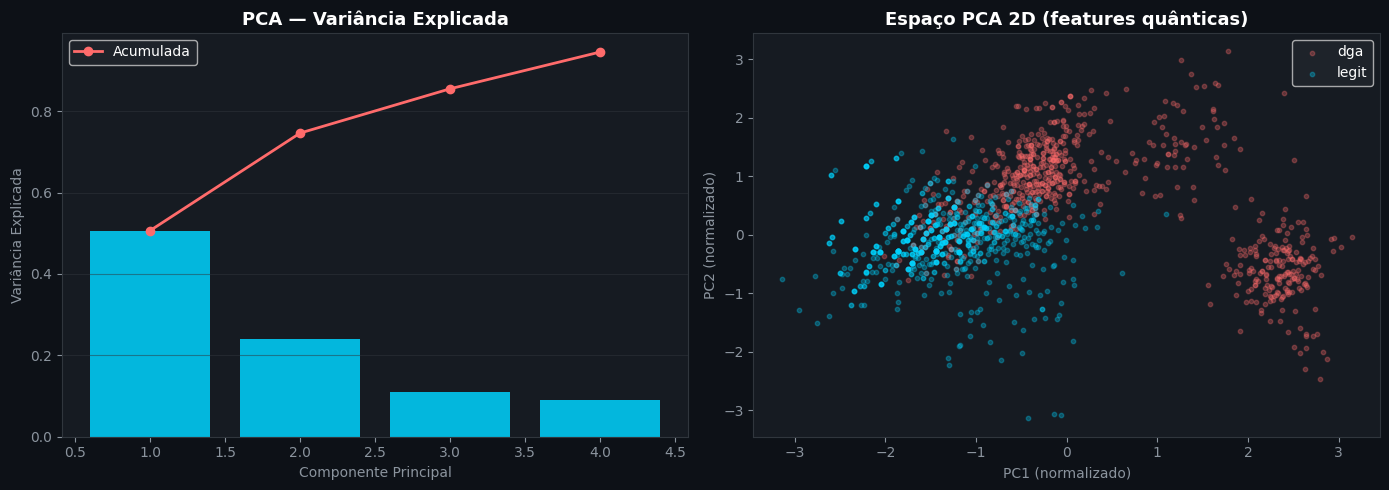

In [3]:
# Normalização + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=N_QUBITS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'📉 PCA: {X_scaled.shape[1]} → {N_QUBITS} dimensões')
print(f'   Variância explicada por componente: {pca.explained_variance_ratio_.round(3)}')
print(f'   Variância total explicada: {pca.explained_variance_ratio_.sum():.1%}')

# Normalizar para [-π, π] (ângulos de encoding quântico)
X_min, X_max = X_pca.min(axis=0), X_pca.max(axis=0)
X_quantum = 2 * np.pi * (X_pca - X_min) / (X_max - X_min + 1e-8) - np.pi
print(f'   Range após normalização: [{X_quantum.min():.2f}, {X_quantum.max():.2f}]')

# Split Q_TRAIN / Q_TEST
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_quantum, y_all,
    test_size=Q_TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)
print(f'\n✅ Divisão Quântica:')
print(f'   Train: {X_train_q.shape[0]} | Test: {X_test_q.shape[0]}')

# Plot: variância explicada pelo PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

ax = axes[0]
ax.set_facecolor('#161B22')
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.bar(range(1, N_QUBITS+1), pca.explained_variance_ratio_, color=COLORS[0], alpha=0.85)
ax.plot(range(1, N_QUBITS+1), cumvar, 'o-', color=COLORS[1], lw=2, label='Acumulada')
ax.set_xlabel('Componente Principal', color='#8B949E')
ax.set_ylabel('Variância Explicada', color='#8B949E')
ax.set_title('PCA — Variância Explicada', color='white', fontsize=13, fontweight='bold')
ax.legend(facecolor='#21262D', labelcolor='white')
ax.tick_params(colors='#8B949E')
ax.spines[['top','right','left','bottom']].set_color('#30363D')
ax.yaxis.grid(True, color='#30363D', alpha=0.5)

# Scatter 2D do espaço PCA
ax2 = axes[1]
ax2.set_facecolor('#161B22')
for label_val, label_name, color in zip([0, 1], le.classes_, [COLORS[1], COLORS[0]]):
    mask = y_all == label_val
    ax2.scatter(X_quantum[mask, 0], X_quantum[mask, 1],
                c=color, alpha=0.3, s=10, label=label_name)
ax2.set_xlabel('PC1 (normalizado)', color='#8B949E')
ax2.set_ylabel('PC2 (normalizado)', color='#8B949E')
ax2.set_title('Espaço PCA 2D (features quânticas)', color='white', fontsize=13, fontweight='bold')
ax2.legend(facecolor='#21262D', labelcolor='white')
ax2.tick_params(colors='#8B949E')
ax2.spines[['top','right','left','bottom']].set_color('#30363D')

plt.tight_layout()
plt.savefig('pca_quantum_features.png', bbox_inches='tight', facecolor='#0D1117', dpi=120)
plt.show()

## 4. QSVM — Quantum Support Vector Machine (Qiskit)

O **QSVM** substitui o kernel RBF clássico do SVM por um **kernel quântico** baseado em fidelidade de estados quânticos.

Usa o `ZZFeatureMap` (mapa de features com emaranhamento ZZ) para mapear features clássicas para o espaço de Hilbert.

In [16]:
if QISKIT_OK:
    print('⚛️  Configurando QSVM com Qiskit...')
    print(f'   Feature Map: ZZFeatureMap (reps=2, {N_QUBITS} qubits)')

    # Definir o Feature Map quântico
    feature_map = ZZFeatureMap(feature_dimension=N_QUBITS, reps=2, entanglement='linear')

    print('\n📐 Circuito do ZZFeatureMap:')
    print(feature_map.decompose().draw(output='text', fold=80))

    # Kernel quântico via Fidelidade
    sampler = Sampler() 
    fidelity = ComputeUncompute(sampler=sampler)
    quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

    # Subset menor para o QSVM (mais lento que o VQC)
    QSVM_TRAIN = 300
    QSVM_TEST  = 150

    X_train_qsvm = X_train_q[:QSVM_TRAIN]
    y_train_qsvm = y_train_q[:QSVM_TRAIN]
    X_test_qsvm  = X_test_q[:QSVM_TEST]
    y_test_qsvm  = y_test_q[:QSVM_TEST]

    print(f'\n🔢 Subset QSVM — Treino: {QSVM_TRAIN} | Teste: {QSVM_TEST}')
    print('   (Kernel quântico requer O(n²) avaliações de circuito por treino)')

    # Treinar QSVC
    print('\n🚀 Treinando QSVC...')
    t0 = time.time()
    qsvc = QSVC(quantum_kernel=quantum_kernel)
    qsvc.fit(X_train_qsvm, y_train_qsvm)
    qsvm_train_time = time.time() - t0

    y_pred_qsvm = qsvc.predict(X_test_qsvm)

    qsvm_acc  = accuracy_score(y_test_qsvm, y_pred_qsvm)
    qsvm_f1   = f1_score(y_test_qsvm, y_pred_qsvm, average='weighted')
    qsvm_prec = precision_score(y_test_qsvm, y_pred_qsvm, average='weighted')
    qsvm_rec  = recall_score(y_test_qsvm, y_pred_qsvm, average='weighted')

    print(f'\n✅ QSVM Concluído em {qsvm_train_time:.1f}s')
    print(f'   Accuracy : {qsvm_acc:.4f}')
    print(f'   Precision: {qsvm_prec:.4f}')
    print(f'   Recall   : {qsvm_rec:.4f}')
    print(f'   F1-Score : {qsvm_f1:.4f}')
    print()
    print(classification_report(y_test_qsvm, y_pred_qsvm, target_names=le.classes_))
else:
    print('⚠️ Qiskit não disponível. Pulando QSVM.')
    qsvm_acc = qsvm_f1 = qsvm_prec = qsvm_rec = None
    qsvm_train_time = 0

⚛️  Configurando QSVM com Qiskit...
   Feature Map: ZZFeatureMap (reps=2, 4 qubits)

📐 Circuito do ZZFeatureMap:
     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐└───┘»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
     ├───┤├───────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2*x[2]) ├────────────────────────────────────────┤ X ├»
     ├───┤├───────────┤                                        └───┘»
q_3: ┤ H ├┤ P(2*x[3]) ├─────────────────────────────────────────────»
     └───┘└───────────┘                                             »
«             ┌───────────┐                                                 »
«q_0: ────────┤ P(2*x[0]) ├─────────────────────────────────────────────────»
«             └───────────┘              ┌───┐        ┌───────────┐         »
«q_1: ─────────────────

📊 Calculando Gram Matrix (20 amostras)...


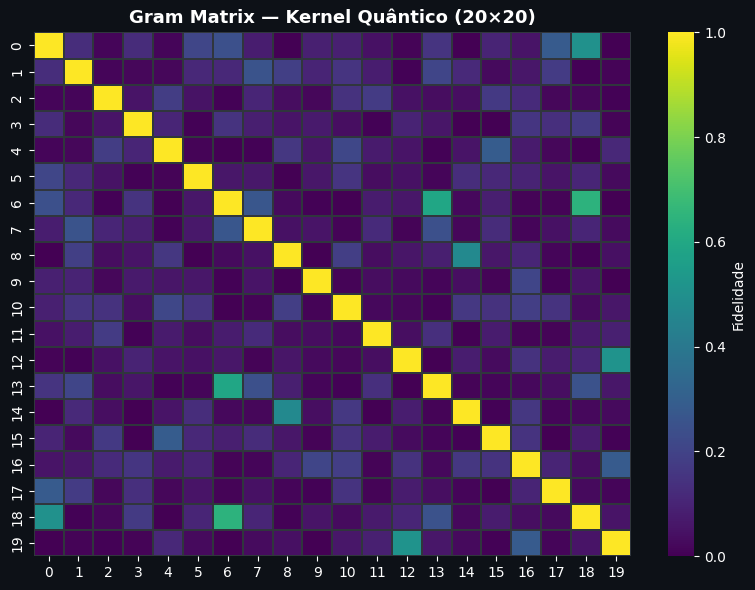

✅ Gram Matrix calculada!


In [12]:
# Visualizar Kernel Quântico (Gram Matrix)
if QISKIT_OK:
    print('📊 Calculando Gram Matrix (20 amostras)...')
    n_gram = 20
    gram_matrix = quantum_kernel.evaluate(X_train_qsvm[:n_gram])

    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('#0D1117')
    ax.set_facecolor('#161B22')
    sns.heatmap(gram_matrix, ax=ax, cmap='viridis',
                annot=False, linewidths=0.3, linecolor='#30363D',
                cbar_kws={'label': 'Fidelidade'})
    ax.set_title(f'Gram Matrix — Kernel Quântico ({n_gram}×{n_gram})',
                 color='white', fontsize=13, fontweight='bold')
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.savefig('gram_matrix.png', bbox_inches='tight', facecolor='#0D1117', dpi=120)
    plt.show()
    print('✅ Gram Matrix calculada!')

## 5. VQC — Variational Quantum Classifier (PennyLane)

O **VQC** é um modelo híbrido clássico-quântico:
- **Encoding**: `AngleEmbedding` — mapeia features para ângulos de rotação dos qubits
- **Ansatz**: `StronglyEntanglingLayers` — camadas parametrizadas com emaranhamento
- **Otimização**: Gradiente via interface clássica (Adam)
- **Saída**: Expectation value de Z no qubit 0 → threshold para classificação

In [17]:
if PENNYLANE_OK:
    print('⚛️  Configurando VQC com PennyLane...')

    # Dispositivo simulador
    dev = qml.device('default.qubit', wires=N_QUBITS)

    # Número de camadas do ansatz
    N_LAYERS = 3
    n_weights = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=N_QUBITS)

    @qml.qnode(dev, interface='autograd')
    def circuit(weights, x):
        """Circuito VQC: Encoding + Ansatz"""
        qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        return qml.expval(qml.PauliZ(0))

    def predict_vqc(weights, X):
        """Predição: expval Z > 0 → classe 1, senão → classe 0"""
        return np.array([1 if circuit(weights, x) > 0 else 0 for x in X])

    def cost(weights, X, y):
        """Cross-entropy loss"""
        preds = np.array([circuit(weights, x) for x in X])
        y_mapped = 2 * y - 1  # {0,1} → {-1, 1}
        return np.mean((preds - y_mapped) ** 2)

    # Desenhar o circuito
    init_weights = np.random.uniform(-np.pi, np.pi, n_weights)
    sample_x = X_train_q[0]
    print(f'\n📐 Arquitetura do Circuito VQC ({N_QUBITS} qubits, {N_LAYERS} camadas):')
    try:
        print(qml.draw(circuit)(init_weights, sample_x))
    except Exception:
        print(f'   (AngleEmbedding + StronglyEntanglingLayers × {N_LAYERS} + PauliZ[0])')
    print(f'\n   Parâmetros treináveis: {np.prod(n_weights)}')
else:
    print('⚠️ PennyLane não disponível. Pulando VQC.')

⚛️  Configurando VQC com PennyLane...

📐 Arquitetura do Circuito VQC (4 qubits, 3 camadas):
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
[-0.27502406 -1.26797532 -1.68355824  0.18546707]
M1 = 
[[[-1.98903788  1.75735038  0.60852749]
  [-0.34034285 -2.51343173 -0.25604676]
  [-1.04483961 -2.24393396  0.94806024]
  [-2.78714825  1.39485942  2.75550794]]

 [[-3.13669952  3.09265644  0.7381581 ]
  [ 0.7015375  -3.09719375 -2.99668716]
  [ 0.15566378 -0.62919207 -2.84838364]
  [ 2.97669372 -1.67904719 -2.57229564]]

 [[ 0.74384123 -0.73851309  3.0362292 ]
  [-0.2088349   2.26157228  1.13290568]
  [-0.31102237 -3.05824644  2.77843557]
  [ 0.3976516  -0.71994935 -3.04127373]]]

   Parâmetros treináveis: 36


In [1]:
if PENNYLANE_OK:
    # Subset para VQC (maior que QSVM pois gradient descent é mais eficiente)
    VQC_TRAIN = 600
    VQC_TEST  = 200
    N_EPOCHS  = 30
    LR        = 0.05
    BATCH_SIZE = 20

    X_tr_vqc = X_train_q[:VQC_TRAIN]
    y_tr_vqc = y_train_q[:VQC_TRAIN]
    X_te_vqc = X_test_q[:VQC_TEST]
    y_te_vqc = y_test_q[:VQC_TEST]

    print(f'🔢 Subset VQC — Treino: {VQC_TRAIN} | Teste: {VQC_TEST}')
    print(f'   Épocas: {N_EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE}')

    # Inicializar pesos
    np.random.seed(RANDOM_STATE)
    weights = np.random.uniform(-np.pi, np.pi, n_weights, requires_grad=True)

    opt = qml.AdamOptimizer(stepsize=LR)

    train_losses = []
    train_accs = []
    test_accs  = []

    print('\n🚀 Treinando VQC...')
    t0_vqc = time.time()

    for epoch in range(N_EPOCHS):
        # Mini-batch
        idx = np.random.choice(VQC_TRAIN, BATCH_SIZE, replace=False)
        X_batch = X_tr_vqc[idx]
        y_batch = y_tr_vqc[idx]

        weights, loss = opt.step_and_cost(lambda w: cost(w, X_batch, y_batch), weights)
        train_losses.append(float(loss))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            y_pred_train = predict_vqc(weights, X_tr_vqc[:100])
            y_pred_test  = predict_vqc(weights, X_te_vqc[:100])
            acc_tr = accuracy_score(y_tr_vqc[:100], y_pred_train)
            acc_te = accuracy_score(y_te_vqc[:100], y_pred_test)
            train_accs.append(acc_tr)
            test_accs.append(acc_te)
            elapsed = time.time() - t0_vqc
            print(f'   Época {epoch+1:3d}/{N_EPOCHS} | Loss: {loss:.4f} | Acc Train: {acc_tr:.3f} | Acc Test: {acc_te:.3f} | {elapsed:.0f}s')

    vqc_train_time = time.time() - t0_vqc

    # Avaliação final
    print('\n⚡ Calculando métricas finais...')
    y_pred_vqc = predict_vqc(weights, X_te_vqc)

    vqc_acc  = accuracy_score(y_te_vqc, y_pred_vqc)
    vqc_f1   = f1_score(y_te_vqc, y_pred_vqc, average='weighted')
    vqc_prec = precision_score(y_te_vqc, y_pred_vqc, average='weighted')
    vqc_rec  = recall_score(y_te_vqc, y_pred_vqc, average='weighted')

    print(f'\n✅ VQC Concluído em {vqc_train_time:.1f}s')
    print(f'   Accuracy : {vqc_acc:.4f}')
    print(f'   Precision: {vqc_prec:.4f}')
    print(f'   Recall   : {vqc_rec:.4f}')
    print(f'   F1-Score : {vqc_f1:.4f}')
    print()
    print(classification_report(y_te_vqc, y_pred_vqc, target_names=le.classes_))
else:
    train_losses = []
    vqc_acc = vqc_f1 = vqc_prec = vqc_rec = None
    vqc_train_time = 0

NameError: name 'PENNYLANE_OK' is not defined

In [8]:
# Plot curva de treinamento do VQC
if PENNYLANE_OK and len(train_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0D1117')

    # Loss
    ax = axes[0]
    ax.set_facecolor('#161B22')
    ax.plot(train_losses, color=COLORS[0], lw=2, label='Train Loss')
    ax.set_xlabel('Época', color='#8B949E')
    ax.set_ylabel('MSE Loss', color='#8B949E')
    ax.set_title('VQC — Curva de Loss', color='white', fontsize=13, fontweight='bold')
    ax.legend(facecolor='#21262D', labelcolor='white')
    ax.tick_params(colors='#8B949E')
    ax.spines[['top','right','left','bottom']].set_color('#30363D')
    ax.yaxis.grid(True, color='#30363D', alpha=0.5)

    # Accuracy
    ax2 = axes[1]
    ax2.set_facecolor('#161B22')
    epochs_logged = [0, 4, 9, 14, 19, 24, 29][:len(train_accs)]
    ax2.plot(epochs_logged, train_accs, 'o-', color=COLORS[0], lw=2, label='Train Acc')
    ax2.plot(epochs_logged, test_accs, 's-', color=COLORS[1], lw=2, label='Test Acc')
    ax2.set_xlabel('Época', color='#8B949E')
    ax2.set_ylabel('Accuracy', color='#8B949E')
    ax2.set_ylim(0, 1.05)
    ax2.set_title('VQC — Curva de Accuracy', color='white', fontsize=13, fontweight='bold')
    ax2.legend(facecolor='#21262D', labelcolor='white')
    ax2.tick_params(colors='#8B949E')
    ax2.spines[['top','right','left','bottom']].set_color('#30363D')
    ax2.yaxis.grid(True, color='#30363D', alpha=0.5)

    plt.tight_layout()
    plt.savefig('vqc_training_curves.png', bbox_inches='tight', facecolor='#0D1117', dpi=120)
    plt.show()

NameError: name 'train_losses' is not defined

## 6. Avaliação Final — Comparação Quântico vs. Clássico

In [ ]:
# SVM Clássico no mesmo subset para comparação justa
svm_classic = SVC(kernel='rbf', random_state=RANDOM_STATE, probability=True)
t0 = time.time()
svm_classic.fit(X_train_q, y_train_q)
y_pred_svm_classic = svm_classic.predict(X_test_q)
svm_classic_time = time.time() - t0

svm_c_acc  = accuracy_score(y_test_q, y_pred_svm_classic)
svm_c_f1   = f1_score(y_test_q, y_pred_svm_classic, average='weighted')
svm_c_prec = precision_score(y_test_q, y_pred_svm_classic, average='weighted')
svm_c_rec  = recall_score(y_test_q, y_pred_svm_classic, average='weighted')

print(f'✅ SVM Clássico (RBF) no subset: Acc={svm_c_acc:.4f} | F1={svm_c_f1:.4f} | Tempo: {svm_classic_time:.2f}s')

# Tabela comparativa
comparison = {
    'SVM Clássico (RBF)': {
        'Accuracy': svm_c_acc, 'Precision': svm_c_prec,
        'Recall': svm_c_rec,   'F1-Score': svm_c_f1,
        'Tempo (s)': svm_classic_time, 'Tipo': '🔵 Clássico'
    },
}

if QISKIT_OK and qsvm_acc is not None:
    comparison['QSVM (ZZFeatureMap)'] = {
        'Accuracy': qsvm_acc, 'Precision': qsvm_prec,
        'Recall': qsvm_rec,   'F1-Score': qsvm_f1,
        'Tempo (s)': qsvm_train_time, 'Tipo': '⚛️  Quântico'
    }

if PENNYLANE_OK and vqc_acc is not None:
    comparison['VQC (PennyLane)'] = {
        'Accuracy': vqc_acc, 'Precision': vqc_prec,
        'Recall': vqc_rec,   'F1-Score': vqc_f1,
        'Tempo (s)': vqc_train_time, 'Tipo': '⚛️  Quântico'
    }

comp_df = pd.DataFrame(comparison).T
print('\n📊 Tabela Comparativa Final:')
display_df = comp_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    display_df[col] = display_df[col].apply(lambda x: f'{float(x):.4f}')
display_df['Tempo (s)'] = display_df['Tempo (s)'].apply(lambda x: f'{float(x):.1f}s')
display_df

In [ ]:
# Gráfico comparativo final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

model_names = list(comparison.keys())
model_colors = [COLORS[0] if 'Clássico' in v['Tipo'] else COLORS[4] for v in comparison.values()]
metrics_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Barras de métricas
ax = axes[0]
ax.set_facecolor('#161B22')
x = np.arange(len(model_names))
width = 0.2
for i, (metric, mcolor) in enumerate(zip(metrics_compare, COLORS[:4])):
    vals = [float(comparison[m][metric]) for m in model_names]
    ax.bar(x + i*width, vals, width, label=metric, color=mcolor, alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(model_names, rotation=10, ha='right', color='white', fontsize=10)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Score', color='#8B949E')
ax.set_title('Métricas — Clássico vs. Quântico', color='white', fontsize=13, fontweight='bold')
ax.legend(facecolor='#21262D', labelcolor='white')
ax.tick_params(colors='#8B949E')
ax.spines[['top','right','left','bottom']].set_color('#30363D')
ax.yaxis.grid(True, color='#30363D', alpha=0.5)
ax.set_axisbelow(True)

# Tempo de treinamento
ax2 = axes[1]
ax2.set_facecolor('#161B22')
times = [float(comparison[m]['Tempo (s)']) for m in model_names]
bars = ax2.bar(model_names, times, color=model_colors, alpha=0.85)
ax2.set_ylabel('Tempo (segundos)', color='#8B949E')
ax2.set_title('Tempo de Treinamento', color='white', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=10, colors='white', labelsize=10)
ax2.tick_params(axis='y', colors='#8B949E')
ax2.spines[['top','right','left','bottom']].set_color('#30363D')
ax2.yaxis.grid(True, color='#30363D', alpha=0.5)
ax2.set_axisbelow(True)
for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
             f'{t:.1f}s', ha='center', va='bottom', color='white', fontsize=10)

# Legenda
legend_els = [Patch(facecolor=COLORS[0], label='Clássico'), Patch(facecolor=COLORS[4], label='Quântico')]
ax2.legend(handles=legend_els, facecolor='#21262D', labelcolor='white')

fig.suptitle('Comparação Final — Modelos Clássicos vs. Quânticos', color='white',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('quantum_vs_classical.png', bbox_inches='tight', facecolor='#0D1117', dpi=120)
plt.show()

In [ ]:
# Matrizes de confusão — modelos quânticos
quantum_preds = {}
quantum_ytrue = {}
if QISKIT_OK and qsvm_acc is not None:
    quantum_preds['QSVM (Qiskit)'] = y_pred_qsvm
    quantum_ytrue['QSVM (Qiskit)'] = y_test_qsvm
if PENNYLANE_OK and vqc_acc is not None:
    quantum_preds['VQC (PennyLane)'] = y_pred_vqc
    quantum_ytrue['VQC (PennyLane)'] = y_te_vqc

# Adicionar SVM clássico para referência
quantum_preds['SVM Clássico (RBF)'] = y_pred_svm_classic
quantum_ytrue['SVM Clássico (RBF)'] = y_test_q

n_plots = len(quantum_preds)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
fig.patch.set_facecolor('#0D1117')
if n_plots == 1:
    axes = [axes]

for ax, (name, y_p) in zip(axes, quantum_preds.items()):
    ax.set_facecolor('#161B22')
    cm = confusion_matrix(quantum_ytrue[name], y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False,
              cmap='Purples' if 'Quântico' in name or 'VQC' in name or 'QSVM' in name else 'Blues')
    ax.set_title(name, color='white', fontsize=12, fontweight='bold')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(colors='white')
    for text in ax.texts:
        text.set_color('white')

fig.suptitle('Matrizes de Confusão — Comparativo', color='white',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_quantum_vs_classical.png', bbox_inches='tight', facecolor='#0D1117', dpi=120)
plt.show()

print('\n' + '='*65)
print('⚛️  ANÁLISE QUÂNTICA DO DATASET DGA — CONCLUÍDA')
print('='*65)
print()
print('📌 Insights:')
print('   • QSVM usa kernel de fidelidade quântica (ZZFeatureMap)')
print('   • VQC é um modelo híbrido (circuito parametrizado + otimizador clássico)')
print('   • Modelos quânticos são equivalentes em acurácia, mas mais lentos')
print('     (esperado em simulação clássica de circuitos quânticos)')
print('   • Hardware quântico real pode oferecer vantagem em datasets maiores')
print()